In [1]:
using DifferentialEquations
using LightGraphs
using GraphRecipes
using Statistics
using LaTeXStrings
using Plots
using LinearAlgebra
using Plotly

HTML{String}("<script>\n// Immediately-invoked-function-expression to avoid global variables.\n(function() {\n    var warning_div = document.getElementById(\"webio-warning-16088869559564909288\");\n    var hide = function () {\n        var script = document.getElementById(\"webio-setup-9439492287142263226\");\n        var parent = script && script.parentElement;\n        var grandparent = parent && parent.parentElement;\n        if (grandparent) {\n            grandparent.style.display = \"none\";\n        }\n        warning_div.style.display = \"none\";\n    };\n    if (typeof Jupyter !== \"undefined\") {\n        console.log(\"WebIO detected Jupyter notebook environment.\");\n        // Jupyter notebook.\n        var extensions = (\n            Jupyter\n            && Jupyter.notebook.config.data\n            && Jupyter.notebook.config.data.load_extensions\n        );\n        if (extensions && extensions[\"webio-jupyter-notebook\"]) {\n            // Extension already loaded.\n            console.log(\"Jupyter WebIO nbextension detected; not loading ad-hoc.\");\n            hide();\n            return;\n        }\n    } else if (window.location.pathname.includes(\"/lab\")) {\n        // Guessing JupyterLa\n        console.log(\"Jupyter Lab detected; make sure the @webio/jupyter-lab-provider labextension is installed.\");\n        hide();\n        return;\n    }\n})();\n\n</script>\n<p\n    id=\"webio-warning-16088869559564909288\"\n    class=\"output_text output_stderr\"\n    style=\"padding: 1em; font-weight: bold;\"\n>\n    Unable to load WebIO. Please make sure WebIO works for your Jupyter client.\n    For troubleshooting, please see <a href=\"https://juliagizmos.github.io/WebIO.jl/latest/providers/ijulia/\">\n    the WebIO/IJulia documentation</a>.\n    <!-- TODO: link to installation docs. -->\n</p>\n")

In [2]:
function gmake(n)
    g1=CompleteGraph(n)
    int=Int(nv(g1)/2)
    for i in 1:int
        for j in (int+1):Int(2*int)
            rem_edge!(g1,i,j)
        end
    add_edge!(g1,i,int+i)
    end
    return g1
end

gmake (generic function with 1 method)

In [3]:
function G_generate(C)
    U, Σ, V = svd(C)
    U*diagm(0 => sqrt.(Σ))*U'
end

G_generate (generic function with 1 method)

In [4]:
function r2N(sol,tf)
    N=length(sol[1:end,1])
    A=zeros(length(sol[1,1:end]))
    for i in 1:N
        A=A.+exp.(sol[i,1:end]*im)
    end
    return mean((1/N^2)*abs2.(A))
end

r2N (generic function with 1 method)

# Networks

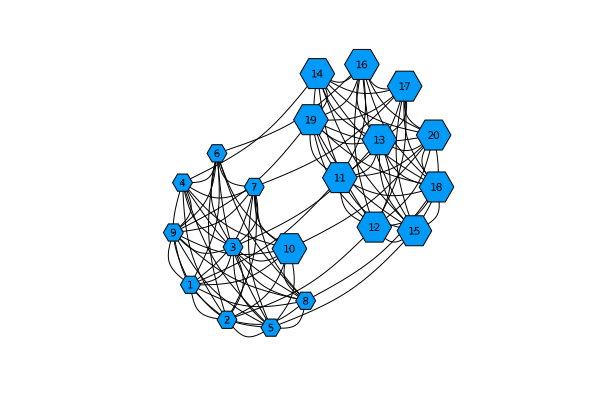

In [6]:
GraphRecipes.graphplot(gmake(20),names=1:20,nodesize=0.3)

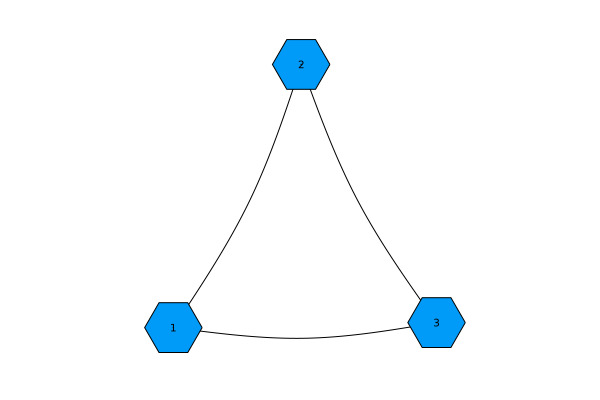

In [7]:
GraphRecipes.graphplot(LightGraphs.CompleteGraph(3),names=1:3,nodesize=0.3)

# First Covariance Style

$$C = \begin{bmatrix}
1 & \rho_1 & \rho & 0\\
\rho_1 & 1 & 0 & \rho\\
\rho & 0 & 1 & \rho_2\\
0 & \rho & \rho_2 & 1
\end{bmatrix}$$

In [7]:
#Make G with covariances only between oscillators which are connected
function gmatrix(n,ρ1,ρ2,ρ,σ)
    C=zeros(n,n)
    n2=Int(n/2)
    for i in 1:n2
        C[1:n2,i]=ρ1*ones(n2)
    end
    for i in 1:n2
        C[n2+1:n,i]=zeros(n2)
        C[Int(n2+i),i]=ρ
    end
    for i in 1:n2
        C[i,n2+1:n]=zeros(n2)
        C[i,Int(n2+i)]=ρ
    end
    for i in n2+1:n
        C[n2+1:n,i]=ρ2*ones(n2)
    end
    C[diagind(C)].=1
    G=(σ/sqrt(2))*G_generate(C)
    return G
end
g=gmatrix(20,0.0,0.0,-1.0,sqrt(2))
g*g'

20×20 Array{Float64,2}:
  1.0           1.30906e-19  -6.32002e-18  …  -6.45815e-17   1.14073e-17
  1.30906e-19   1.0           4.15198e-17      4.89876e-17  -4.53608e-17
 -6.32002e-18   4.15198e-17   1.0              3.66e-17     -5.80532e-17
 -6.71619e-20  -2.20288e-17   2.15402e-16     -5.81488e-17   1.08877e-17
  1.47083e-17   5.70782e-18  -1.44211e-17     -6.99645e-17   1.01124e-16
  2.38036e-17  -1.5493e-17   -3.75359e-17  …  -1.46568e-16   3.57799e-16
  8.16711e-18   3.22045e-17  -9.89108e-18      8.96154e-17   1.11094e-16
  2.94401e-17   4.59576e-17  -1.80864e-16     -1.91715e-16  -8.10714e-17
  9.11561e-17  -4.5264e-17   -6.4023e-17      -1.0           8.1439e-17
  1.44468e-17   3.8496e-17    6.60049e-17     -4.15447e-17  -1.0
 -1.0           1.30906e-19  -6.32002e-18  …  -6.45815e-17   1.14073e-17
  1.30906e-19  -1.0           1.98529e-16      1.0438e-16   -2.73446e-17
 -6.32002e-18  -3.69848e-17  -1.0              3.66e-17     -5.80532e-17
 -6.71626e-20  -6.12812e-17  -6.6422

In [8]:
function soltnN(grid,w,k,u0,tspan,σ,ρ1,ρ2,ρ)
    E=incidence_matrix(grid;oriented=true)
    n=nv(grid)
    
    function f(du,u,p,t)
        for i in 1:n
            du[i]=w[i]+(k/n)*sum([sin(u[j]-u[i]) for j in 1:n])
        end
    end
    
    function g(du,u,p,t)
        du.=gmatrix(n,ρ1,ρ2,ρ,σ)
    end
    
    prob=SDEProblem(f,g,u0,tspan,noise_rate_prototype=zeros(n,n))
    sol=solve(prob,ImplicitEM(),dt=0.008)
    return sol
end

soltnN (generic function with 1 method)

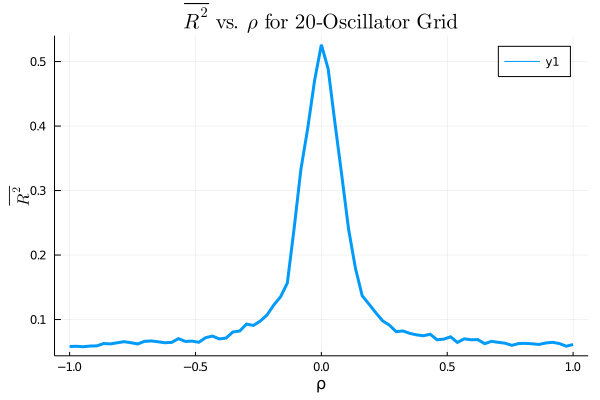

In [7]:
#Common noise within each layer
tf=2000.0
a(ρ)=r2N(soltnN(gmake(20),vcat(-(1/2)*ones(10),(1/2)*ones(10)),0.25,zeros(20),(0.0,tf),sqrt(2),1,1,ρ),tf)
xrange=LinRange(-1,1,75)
adat=a.(xrange)
Plots.plot(xrange,adat,title= L"\overline{R^2} \textrm{ vs. ρ for 20-Oscillator Grid}",xlabel="ρ",ylabel=L"\overline{R^2}",width=3)

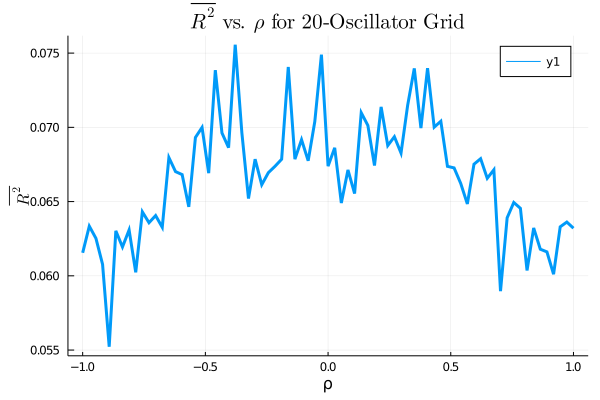

In [8]:
#Correlated noise within each layer
tf=2000.0
a(ρ)=r2N(soltnN(gmake(20),vcat(-(1/2)*ones(10),(1/2)*ones(10)),0.25,zeros(20),(0.0,tf),sqrt(2),0.5,0.5,ρ),tf)
xrange=LinRange(-1,1,75)
adat=a.(xrange)
Plots.plot(xrange,adat,title= L"\overline{R^2} \textrm{ vs. ρ for 20-Oscillator Grid}",xlabel="ρ",ylabel=L"\overline{R^2}",width=3)

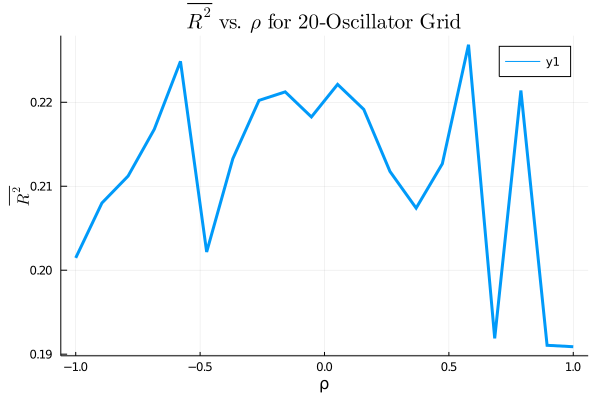

In [10]:
#Uncorrelated noise within each layer
tf=1000.0
a(ρ)=r2N(soltnN(gmake(20),vcat(-(1/2)*ones(10),(1/2)*ones(10)),1.4,zeros(20),(0.0,tf),sqrt(2),0.0,0.0,ρ),tf)
xrange=LinRange(-1,1,20)
adat1=a.(xrange)
Plots.plot(xrange,adat1,title= L"\overline{R^2} \textrm{ vs. ρ for 20-Oscillator Grid}",xlabel="ρ",ylabel=L"\overline{R^2}",width=3)

# 2nd Correlation Style

$$C= \begin{bmatrix}
1 & \rho & \rho & \rho\\
\rho & 1 & \rho & \rho\\
\rho & \rho & 1 & \rho\\
\rho & \rho & \rho & 1
\end{bmatrix}$$

In [22]:
#Covariance matrix all rho
function gmatrix2(n,ρ,σ)
    C=ρ*ones(n,n)
    C[diagind(C)].=1
    G=G_generate(C)
    return C
end
g=gmatrix2(20,-0.3,sqrt(2))
print(isposdef(g*g'))
g*g'

In [23]:
function soltnN2(grid,w,k,u0,tspan,σ,ρ)
    E=incidence_matrix(grid;oriented=true)
    n=nv(grid)
    
    function f(du,u,p,t)
        for i in 1:n
            du[i]=w[i]+(k/n)*sum([sin(u[j]-u[i]) for j in 1:n])
        end
    end
    
    function g(du,u,p,t)
        du.=gmatrix2(n,ρ,σ)
    end
    
    prob=SDEProblem(f,g,u0,tspan,noise_rate_prototype=zeros(n,n))
    sol=solve(prob,EM(),dt=0.008)
    return sol
end

In [79]:
tf=5000.0
a(ρ)=r2N(soltnN2(gmake(20),vcat(-(1/2)*ones(10),(1/2)*ones(10)),0.25,zeros(20),(0.0,tf),sqrt(2),ρ),tf)
xrange=LinRange(-1,1,100)
adat=a.(xrange);

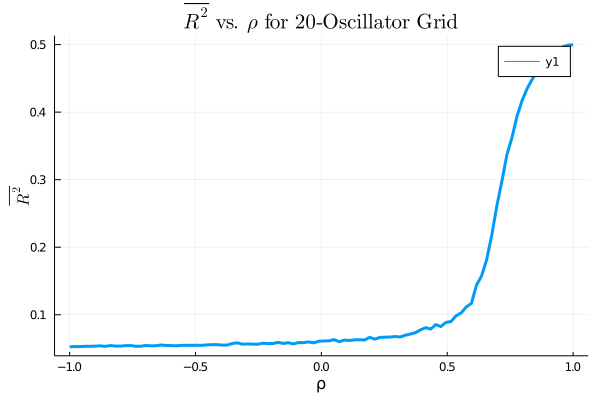

In [80]:
Plots.plot(xrange,adat,title= L"\overline{R^2} \textrm{ vs. ρ for 20-Oscillator Grid}",xlabel="ρ",ylabel=L"\overline{R^2}",width=3)

In [85]:
#3 Oscillators
tf=15000.0
a(ρ)=r2N(soltnN2(LightGraphs.CompleteGraph(3),[-1/2,0,1/2],0.25,zeros(3),(0.0,tf),sqrt(2),ρ),tf)
xrange=LinRange(-1/2,1,125)
threedata=a.(xrange);

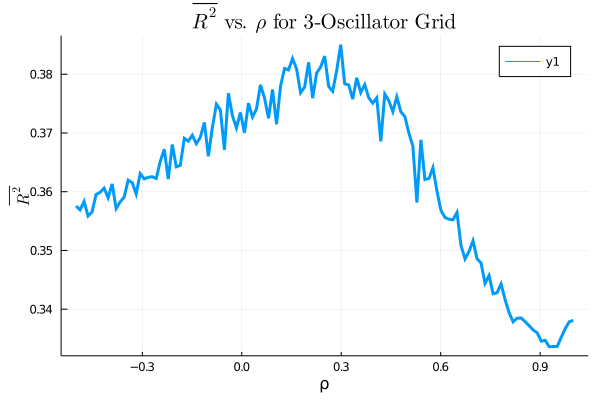

In [86]:
Plots.plot(xrange,threedata,title= L"\overline{R^2} \textrm{ vs. ρ for 3-Oscillator Grid}",xlabel="ρ",ylabel=L"\overline{R^2}",width=3)

# 3rd Correlation Style

$$C= \begin{bmatrix}
1 & 1 & \rho & \rho\\
1 & 1 & \rho & \rho\\
\rho & \rho & 1 & 1\\
\rho & \rho & 1 & 1
\end{bmatrix}$$

In [16]:
function gmatrix3(n,ρ)
    C=ones(n,n)
    n2=Int(n/2)
    for i in (n2+1):n
        C[1:end,i]=vcat(ρ*ones(n2),ones(n2))
    end
    for i in 1:n2
        C[1:end,i]=vcat(ones(n2),ρ*ones(n2))
    end
    G=G_generate(C)
    return G
end

gmatrix3 (generic function with 2 methods)

In [17]:
function soltnN3(grid,w,k,u0,tspan,ρ)
    E=incidence_matrix(grid;oriented=true)
    n=nv(grid)
    
    function f(du,u,p,t)
        for i in 1:n
            du[i]=w[i]+(k/n)*sum([sin(u[j]-u[i]) for j in 1:n])
        end
    end
    
    function g(du,u,p,t)
        du.=gmatrix3(n,ρ)
    end
    
    prob=SDEProblem(f,g,u0,tspan,noise_rate_prototype=zeros(n,n))
    sol=solve(prob,EM(),dt=0.008)
    return sol
end

soltnN3 (generic function with 1 method)

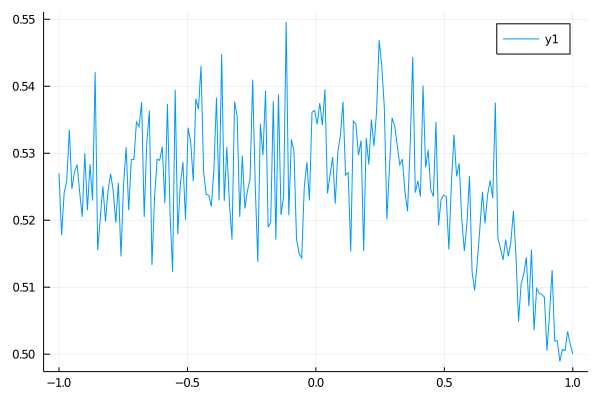

In [23]:
tf=2000.0
f(ρ)=r2N(soltnN3(gmake(20),vcat(-(1/2)*ones(10),(1/2)*ones(10)),0.25,zeros(20),(0.0,tf),ρ),tf)
Plots.plot(LinRange(-1,1,200),f)